### **ANALIZANDO TABLA PRIMARIA**

In [1]:
import pandas as pd
import numpy as np

# Definir tipos de datos reducidos para optimizar el uso de RAM desde la carga
dtypes_optimizados = {
    'SK_ID_CURR': 'int32',
    'TARGET': 'int8',
    'NAME_CONTRACT_TYPE': 'category',
    'CODE_GENDER': 'category',
    'FLAG_OWN_CAR': 'category',
    'FLAG_OWN_REALTY': 'category'
}

# Cargar la tabla principal desde la carpeta raw
df_train = pd.read_csv('../data/raw/application_train.csv', dtype=dtypes_optimizados)

# Verificar dimensiones y evaluar el consumo exacto de memoria RAM
print(f"Dimensiones del dataset principal: {df_train.shape}")
print("\nInformación de consumo de memoria:")
df_train.info(memory_usage='deep')

Dimensiones del dataset principal: (307511, 122)

Información de consumo de memoria:
<class 'pandas.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: category(4), float64(65), int32(1), int64(39), int8(1), str(12)
memory usage: 441.5 MB


Muestra de datos financieros clave:


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,AMT_INCOME_TOTAL,AMT_CREDIT
0,100002,1,Cash loans,M,202500.0,406597.5
1,100003,0,Cash loans,F,270000.0,1293502.5
2,100004,0,Revolving loans,M,67500.0,135000.0
3,100006,0,Cash loans,F,135000.0,312682.5
4,100007,0,Cash loans,M,121500.0,513000.0


C:\Users\SEBASTIAN\AppData\Local\Temp\ipykernel_17712\3919776262.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_train, x='TARGET', palette='Set2')


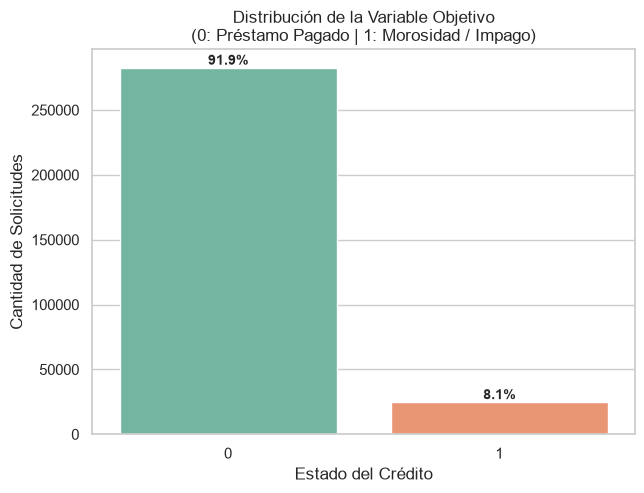

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar el estilo visual de los gráficos
sns.set_theme(style="whitegrid")

# 1. Visualizar una muestra de las columnas financieras clave
columnas_clave = ['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER', 'AMT_INCOME_TOTAL', 'AMT_CREDIT']
print("Muestra de datos financieros clave:")
display(df_train[columnas_clave].head())

# 2. Graficar el desbalance de la variable objetivo
plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df_train, x='TARGET', hue='TARGET', palette='Set2', legend=False)
plt.title('Distribución de la Variable Objetivo\n(0: Préstamo Pagado | 1: Morosidad / Impago)', fontsize=12)
plt.xlabel('Estado del Crédito')
plt.ylabel('Cantidad de Solicitudes')

# Añadir las etiquetas de porcentaje sobre cada barra
total = len(df_train)
for p in ax.patches:
    porcentaje = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(porcentaje, (x, y), ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.show()

In [3]:
# Calcular el porcentaje exacto de valores nulos por columna
nulos = df_train.isnull().mean() * 100
# Filtrar solo las que tienen nulos y ordenarlas de mayor a menor
nulos = nulos[nulos > 0].sort_values(ascending=False)

print(f"Total de columnas con valores nulos: {len(nulos)} de {df_train.shape[1]}")
print("\nTop 20 columnas con mayor porcentaje de datos faltantes:")
# Mostrar como un dataframe con formato de porcentaje
display(nulos.head(20).to_frame(name='Porcentaje de Nulos').style.format("{:.2f}%"))

Total de columnas con valores nulos: 67 de 122

Top 20 columnas con mayor porcentaje de datos faltantes:


,Porcentaje de Nulos
COMMONAREA_MEDI,69.87%
COMMONAREA_MODE,69.87%
COMMONAREA_AVG,69.87%
NONLIVINGAPARTMENTS_MODE,69.43%
NONLIVINGAPARTMENTS_MEDI,69.43%
NONLIVINGAPARTMENTS_AVG,69.43%
FONDKAPREMONT_MODE,68.39%
LIVINGAPARTMENTS_AVG,68.35%
LIVINGAPARTMENTS_MEDI,68.35%
LIVINGAPARTMENTS_MODE,68.35%


In [4]:
# Analizar las variables EXT_SOURCE
ext_data = df_train[['TARGET', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']]

print("Porcentaje de nulos en los scores externos:")
display(ext_data.isnull().mean().to_frame(name='Porcentaje de Nulos').style.format("{:.2%}"))

# Calcular correlación con TARGET
correlaciones = ext_data.corr()['TARGET'].sort_values()

print("\nCorrelación de los scores externos con la morosidad (TARGET):")
display(correlaciones.to_frame(name='Correlación de Pearson'))

Porcentaje de nulos en los scores externos:


,Porcentaje de Nulos
TARGET,0.00%
EXT_SOURCE_1,56.38%
EXT_SOURCE_2,0.21%
EXT_SOURCE_3,19.83%



Correlación de los scores externos con la morosidad (TARGET):


,Correlación de Pearson
EXT_SOURCE_3,-0.178919
EXT_SOURCE_2,-0.160472
EXT_SOURCE_1,-0.155317
TARGET,1.000000


### **ANALIZANDO TABLAS SECUNDARIAS**

In [5]:
import os

# Lista de las 6 tablas relacionales secundarias
tablas_secundarias = [
    'bureau.csv', 
    'bureau_balance.csv', 
    'previous_application.csv',
    'POS_CASH_balance.csv', 
    'installments_payments.csv', 
    'credit_card_balance.csv'
]

print("Mapeo de Tablas Secundarias (Historial Relacional):\n" + "-"*55)

peso_total_mb = 0

for tabla in tablas_secundarias:
    ruta = f'../data/raw/{tabla}'
    if os.path.exists(ruta):
        # Leer solo una muestra para ver las columnas y cargar la estructura completa para el tamaño
        df_temp = pd.read_csv(ruta)
        filas, columnas = df_temp.shape
        memoria_mb = df_temp.memory_usage(deep=True).sum() / (1024 * 1024)
        peso_total_mb += memoria_mb
        
        # Identificar qué llaves de conexión tiene esta tabla
        llaves = [col for col in ['SK_ID_CURR', 'SK_ID_BUREAU', 'SK_ID_PREV'] if col in df_temp.columns]
        
        print(f"Archivo: {tabla}")
        print(f"Dimensiones: {filas:,} filas x {columnas} columnas")
        print(f"Llaves de conexión: {llaves}")
        print(f"Consumo en RAM: {memoria_mb:.2f} MB\n")

print("-" * 55)
print(f"Peso total estimado en memoria de las tablas secundarias: {peso_total_mb:.2f} MB")

Mapeo de Tablas Secundarias (Historial Relacional):
-------------------------------------------------------
Archivo: bureau.csv
Dimensiones: 1,716,428 filas x 17 columnas
Llaves de conexión: ['SK_ID_CURR', 'SK_ID_BUREAU']
Consumo en RAM: 472.82 MB

Archivo: bureau_balance.csv
Dimensiones: 27,299,925 filas x 3 columnas
Llaves de conexión: ['SK_ID_BUREAU']
Consumo en RAM: 1718.33 MB

Archivo: previous_application.csv
Dimensiones: 1,670,214 filas x 37 columnas
Llaves de conexión: ['SK_ID_CURR', 'SK_ID_PREV']
Consumo en RAM: 1703.01 MB

Archivo: POS_CASH_balance.csv
Dimensiones: 10,001,358 filas x 8 columnas
Llaves de conexión: ['SK_ID_CURR', 'SK_ID_PREV']
Consumo en RAM: 1060.95 MB

Archivo: installments_payments.csv
Dimensiones: 13,605,401 filas x 8 columnas
Llaves de conexión: ['SK_ID_CURR', 'SK_ID_PREV']
Consumo en RAM: 830.41 MB

Archivo: credit_card_balance.csv
Dimensiones: 3,840,312 filas x 23 columnas
Llaves de conexión: ['SK_ID_CURR', 'SK_ID_PREV']
Consumo en RAM: 846.39 MB

-----